In [1]:
import numpy as np
import pandas
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R3D

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import pycamcal

In [3]:
DATASET_DIR = "./synthetic_calibration_example"
DETECTIONS_DIR = f"{DATASET_DIR}/results/target_detection"
RESULTS_DIR = f"{DATASET_DIR}/results/calibration/"

## Load Calibration Data

In [4]:
from pycamcal.calibration.targets.checkerboard import CheckerboardTarget
from pycamcal.primitives.pose import Pose3D, R3D

import json

# load calibration target info
with open(f"{DATASET_DIR}/dataset/calibration_target_info.json") as f:
    calibration_target_info = json.load(f)

# compose world-space target feature points
target = CheckerboardTarget(**calibration_target_info["params"])
target_pose = Pose3D(
    calibration_target_info["pose"]["position"],
    R3D.from_quat(calibration_target_info["pose"]["orientation"])
)

calibration_target_points = target.get_object_points(target_pose)
print(f"Loaded {len(calibration_target_points)} known scene points")

Loaded 54 known scene points


In [5]:
from pycamcal.calibration.calibration_problem import ImageCaptureObservations

# load calibration target detection results
target_detections_df = pandas.read_csv(f"{DETECTIONS_DIR}/target_feature_detections.csv", index_col="img_fname")

feature_ids = sorted(set(col.split(".")[0] for col in target_detections_df.columns))

# img_fname -> observations
image_observations = {}

for img_fname, row in target_detections_df.iterrows():
    observations = ImageCaptureObservations({
        feature_id: np.array([row[f"{feature_id}.x"], row[f"{feature_id}.y"]])
        for feature_id in feature_ids
    })

    image_observations[img_fname] = observations

print(f"Loaded {len(image_observations)} image observations")

Loaded 20 image observations


In [6]:
from pycamcal.primitives.pose import Pose3D, R3D

camera_poses_truth = {}

poses_df = pandas.read_csv(f"{DATASET_DIR}/dataset/true_camera_poses.csv", index_col="img_fname")

for img_fname, row in poses_df.iterrows():
    pos = row[["x", "y", "z"]].to_numpy()
    att = R3D.from_quat(row[["qx", "qy", "qz", "qw"]])

    camera_poses_truth[img_fname] = Pose3D(pos, att)

print(f"Loaded {len(camera_poses_truth)} surveyed camera poses")

Loaded 20 surveyed camera poses


## Define Calibration Problem

In [7]:
from pycamcal.calibration import CalibrationProblem
from pycamcal.optimization import Fixed, Unknown

calib = CalibrationProblem()

In [8]:
from pycamcal.camera_model import CameraModel, RadialTangentialDistortion

# Define the type of camera model to be fit, with known values/initial guesses filled in.

cmod = CameraModel(
    res_xy=(1200, 1000),

    # fixed known pinhole params
    fx=Fixed(825.829),
    fy=Fixed(866.025),
    cx=Fixed(600.0),
    cy=Fixed(500.0),

    # unknown distortion (with initial guess)
    distortion=RadialTangentialDistortion(
        k1=Unknown(initial=+0.00),
        k2=Unknown(initial=+0.00),
        k3=Unknown(initial=+0.00),
        p1=Unknown(initial=+0.00),
        p2=Unknown(initial=+0.00)
    )
)

calib.add_camera("CAM_000", cmod)

In [9]:
# Add the known calibration target geometry

calib.add_known_scene_points(calibration_target_points)

In [10]:
# Add the observed feature locations

for image_id, observations in image_observations.items():
    # unsurveyed (camera poses unknown)
    # calib.add_observations("CAM_000", image_id, observations, camera_pose=None)

    # surveyed (camera poses known)
    calib.add_observations("CAM_000", image_id, observations, camera_pose=Fixed(camera_poses_truth[image_id]))

In [11]:
print(f"Calibration problem has {len(calib.collect_unknowns())} unknowns")

print(calib)

<class 'pycamcal.optimization.optimization_quantity.Unknown'>
[Unknown(current=0.0), Unknown(current=0.0), Unknown(current=0.0), Unknown(current=0.0), Unknown(current=0.0)]
Calibration problem has 5 unknowns
CalibrationProblem(
  cameras = {'CAM_000': <pycamcal.camera_model.camera_model.CameraModel object at 0x31e3b3af0>},
  scene_points = {'CB-0-0': Fixed([-1.         2.1249998  2.5      ]), 'CB-0-1': Fixed([-0.75       2.1249998  2.5      ]), 'CB-0-2': Fixed([-0.5        2.1249998  2.5      ]), 'CB-0-3': Fixed([-0.25000006  2.1249998   2.5       ]), 'CB-0-4': Fixed([-1.1920929e-07  2.1249998e+00  2.5000000e+00]), 'CB-0-5': Fixed([0.25      2.1249998 2.5      ]), 'CB-0-6': Fixed([0.5       2.1249998 2.5      ]), 'CB-0-7': Fixed([0.7499999 2.1249998 2.5      ]), 'CB-0-8': Fixed([0.99999976 2.1249998  2.5       ]), 'CB-1-0': Fixed([-1.         2.1249998  2.25     ]), 'CB-1-1': Fixed([-0.75       2.1249998  2.25     ]), 'CB-1-2': Fixed([-0.5        2.1249998  2.25     ]), 'CB-1-3': Fixed

## Solve

In [12]:
from pycamcal.calibration.solver import solve

calibrated_cmods = solve(calib, maxiter=2)

<class 'pycamcal.optimization.optimization_quantity.Unknown'>
[Unknown(current=0.0), Unknown(current=0.0), Unknown(current=0.0), Unknown(current=0.0), Unknown(current=0.0)]
Solving calibration problem with 5 unknowns
fun([Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32)])
fun([Traced<float32[]>with<JVPTrace> with
  primal = Array(0., dtype=float32)
  tangent = Traced<float32[]>with<JaxprTrace> with
    pval = (ShapedArray(float32[]), None)
    recipe = JaxprEqnRecipe(eqn_id=2, in_tracers=(Traced<float32[]:JaxprTrace>,), out_tracer_refs=[<weakref at 0x329f554e0; to 'JaxprTracer' at 0x329f55490>], out_avals=[ShapedArray(float32[])], primitive=convert_element_type, params={'new_dtype': dtype('float32'), 'weak_type': False, 'sharding': None}, effects=frozenset(), source_info=<jax._src.source_info_util.SourceInfo object at 0x329f49a20>, ctx=JaxprEqnContext(compute_type=None, threefry_partitionable=True, cur_abst

In [13]:
print("========== Calibrated camera model =========\n")
print(calibrated_cmods["CAM_000"])

========== Calibrated camera model =========

{'res_xy': [1200, 1000],
 'fx': 825.829,
 'fy': 866.025,
 'cx': 600.0,
 'cy': 500.0,
 'distortion': {'model_type': 'RadialTangential',
                'params': {'k1': -0.2510274648666382,
                           'k2': 0.03981749340891838,
                           'k3': -0.0014333128929138184,
                           'p1': 0.008258424699306488,
                           'p2': -0.0019461431074887514}}}


## Evaluate Solution

[329.622 290.359] [329.38437 290.16284]


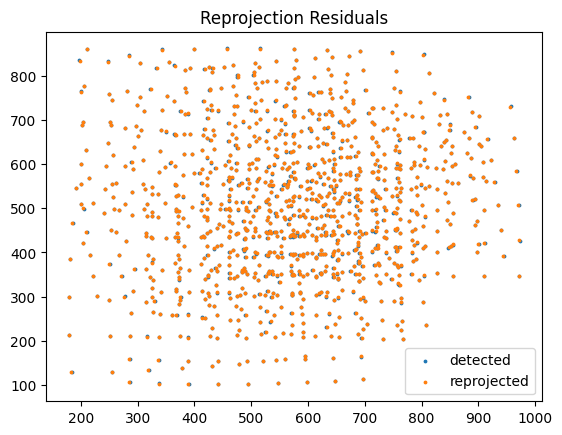

In [14]:
features_detected, featured_reprojected = calib.get_reprojections()

print(features_detected[0], featured_reprojected[0])

plt.title("Reprojection Residuals")

plt.scatter(features_detected[:,0],    features_detected[:,1],    s=3.0, label="detected")
plt.scatter(featured_reprojected[:,0], featured_reprojected[:,1], s=3.0, label="reprojected")

plt.legend()

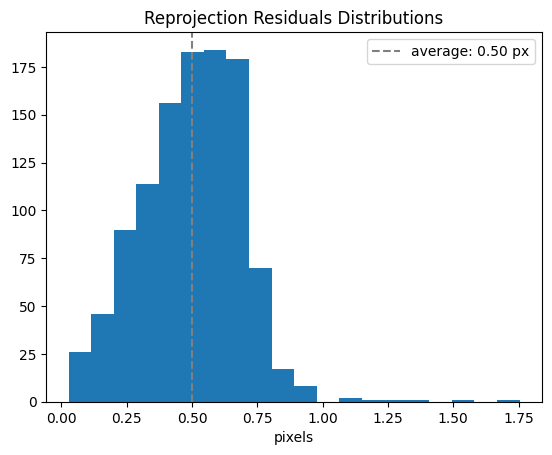

In [15]:
residuals = calib.get_residuals()

residuals_avg = np.mean(residuals)

plt.title("Reprojection Residuals Distributions")

plt.hist(residuals, bins=20)
plt.axvline(residuals_avg, linestyle="--", color="gray", label=f"average: {residuals_avg:.2f} px")
plt.xlabel("pixels")

plt.legend()

## Save Results

In [16]:
camera_model_data = calibrated_cmods["CAM_000"].to_dict()

with open(f"{DATASET_DIR}/results/calibration_surveyed/calibrated_camera_model.json", mode="w+") as f:
    json.dump(camera_model_data, f, indent=4)

In [ ]:
# write a nicely formatted (maybe PDF) calibration "report"